# EDA: train.csv

This notebook performs exploratory data analysis on `data/hackathon-recover-x-cogito/train.csv`.
Sections:
- Import libraries
- Load and inspect data
- Missing values
- Data types and conversions
- Univariate analysis
- (later) Bivariate / Multivariate, Save processed data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Helper for display in notebooks
from IPython.display import display

## Load and Inspect Data
Load `train.csv` and show a quick summary (head, shape, dtypes).

In [2]:
# Load train.csv
file_path = "../data/hackathon-recover-x-cogito/train.csv"
train = pd.read_csv(file_path)

print('Shape:', train.shape)
train.head()


Shape: (1908899, 5)


,id,project_id,room,work_operation_cluster_name,work_operation_cluster_code
0,18299,197011,tilkomstvei,Lett beskyttelse av gulv med dekkepapp,256
1,18299,197011,tilkomstvei,Byggvask,108
2,18299,197011,tilkomstvei,Tildekking av trappetrinn,260
3,18300,270183,Bar,Ny underlag for parkett/laminat,53
4,18300,270183,Bar,Demont gulvlist for gjenbruk,67


## Missing Values
Identify and visualize missingness. Recommend strategies.

In [3]:
# Missing values summary
mv = train.isnull().sum().sort_values(ascending=False)
mv_percent = (train.isnull().mean()*100).sort_values(ascending=False)
missing_df = pd.concat([mv, mv_percent], axis=1)
missing_df.columns = ['missing_count', 'missing_percent']
missing_df[missing_df['missing_count']>0].head(30)

# Simple visualization of top missing columns
top_miss = missing_df[missing_df['missing_count']>0].head(20)
if not top_miss.empty:
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_miss['missing_percent'], y=top_miss.index, palette='mako')
    plt.xlabel('Percent missing')
    plt.title('Top missing columns in train.csv')
    plt.show()
else:
    print('No missing values found in train.csv')


No missing values found in train.csv


## Data type analysis & conversions
Try to convert date-like columns, convert numeric-like strings, and summarize types.

In [4]:
# Show dtypes
train.dtypes

# Detect and convert date-like columns
date_like = [c for c in train.columns if 'date' in c.lower() or 'time' in c.lower()]
for c in date_like:
    train[c] = pd.to_datetime(train[c], errors='coerce')

# Convert object columns that are mostly numeric
for c in train.select_dtypes(include=['object']).columns:
    conv = pd.to_numeric(train[c].str.replace(',', ''), errors='coerce')
    if conv.notnull().sum() >= len(train)*0.8:
        train[c] = conv
        print(f'Converted {c} to numeric')

# Show types after
train.dtypes.value_counts()


int64     3
object    2
Name: count, dtype: int64

## Univariate analysis
- Numeric: describe, histograms, boxplots
- Categorical: top frequencies

Numeric cols: 3 | Categorical cols: 2


,count,mean,std,min,25%,50%,75%,max
id,1908899.0,111061.211443,53528.185497,18299.0,64732.0,111030.0,157403.0,203933.0
project_id,1908899.0,213723.563439,38447.848423,147474.0,180368.0,214261.0,247176.0,280589.0
work_operation_cluster_code,1908899.0,140.213693,104.559428,0.0,55.0,123.0,204.0,387.0


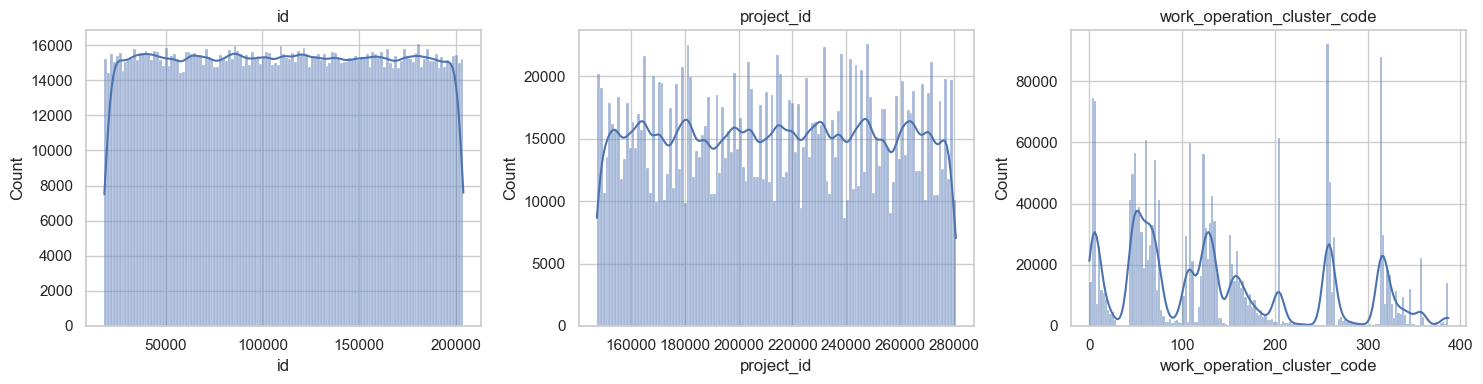


Top for room (unique 15347):


room
Kjøkken          277802
Stue             210554
Gang             190262
Soverom          179307
Bad              105915
Andre områder     89269
Bod               85906
Vaskerom          57366
Soverom 2         40704
Wc                38097
Gang 2            36725
Stue/kjøkken      35375
Kjeller           27078
Utvendig          20560
Bod 2             20182
Stue 2            13873
Kjøkken/stue      13385
Soverom 3         12664
Kjellerstue       12503
Kjøkken 2          9390
Name: count, dtype: int64

C:\Users\tobia\AppData\Local\Temp\ipykernel_15724\4179544982.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


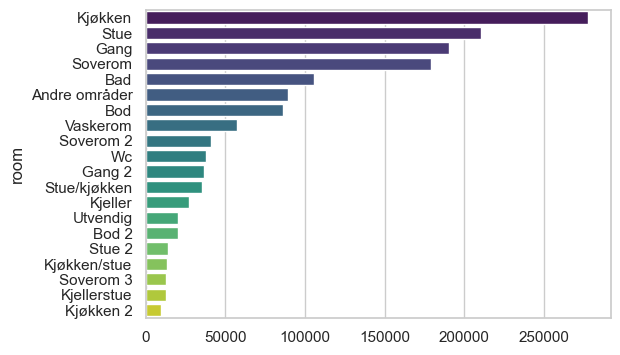


Top for work_operation_cluster_name (unique 367):


work_operation_cluster_name
Lett beskyttelse av gulv med dekkepapp    68603
Byggvask                                  59512
Intern flytting av innbo mellom rom       59020
Ny gulvlist                               52446
Riv gulvlist                              51740
Ny gulv                                   47890
Ny spikerslag/kubbing                     38624
Ny innv karmlist                          37874
Kapping, tverrsaging av plater/panel      37723
Riv flytende gulv                         37017
Ny underlag for parkett/laminat           36541
Riv innv karmlist                         36482
Riv underlagsmateriale                    35363
Ny taklister                              31510
Riv taklist                               30739
Ny dampsperre                             30661
Ny feielist                               30348
Riv feielist                              29297
Riv dampsperre / vindsperre               28355
Ny isolasjon i vegg                       25515
Name: count,

C:\Users\tobia\AppData\Local\Temp\ipykernel_15724\4179544982.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


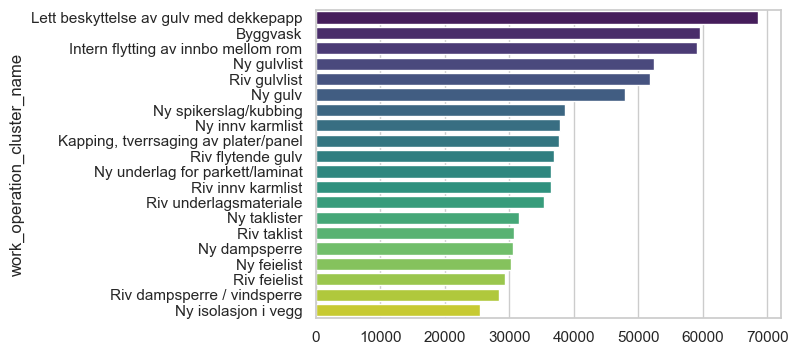


No obvious target column found (named target/label/y).


In [5]:
# Numeric and categorical columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object','category']).columns.tolist()

print(f"Numeric cols: {len(num_cols)} | Categorical cols: {len(cat_cols)}")

if num_cols:
    display(train[num_cols].describe().T)
    # Histograms
    plot_cols = num_cols[:12]
    n = len(plot_cols)
    ncols = 3
    nrows = (n + ncols - 1)//ncols
    plt.figure(figsize=(5*ncols, 4*nrows))
    for i,c in enumerate(plot_cols,1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(train[c].dropna(), kde=True)
        plt.title(c)
    plt.tight_layout()
    plt.show()

if cat_cols:
    for c in cat_cols[:10]:
        vc = train[c].value_counts(dropna=False).head(20)
        print(f"\nTop for {c} (unique {train[c].nunique(dropna=False)}):")
        display(vc)
        plt.figure(figsize=(6, min(4, len(vc)*0.25+1)))
        sns.barplot(x=vc.values, y=vc.index, palette='viridis')
        plt.show()

# If a target-like column exists, show distribution
target_candidates = [c for c in train.columns if c.lower() in ('target','label','y')]
if target_candidates:
    for t in target_candidates:
        print(f"\nTarget distribution for {t}:")
        display(train[t].value_counts(normalize=True))
else:
    print('\nNo obvious target column found (named target/label/y).')


## Per-project job distribution & trends
Plot which work operation clusters occur for each project (scatter with size by count). Also show summary stats: distinct operations per project and total ops vs project creation time (merge with `metaData.csv`).

When the dataset is large we sample or limit to the top projects by operation count to keep plots readable.

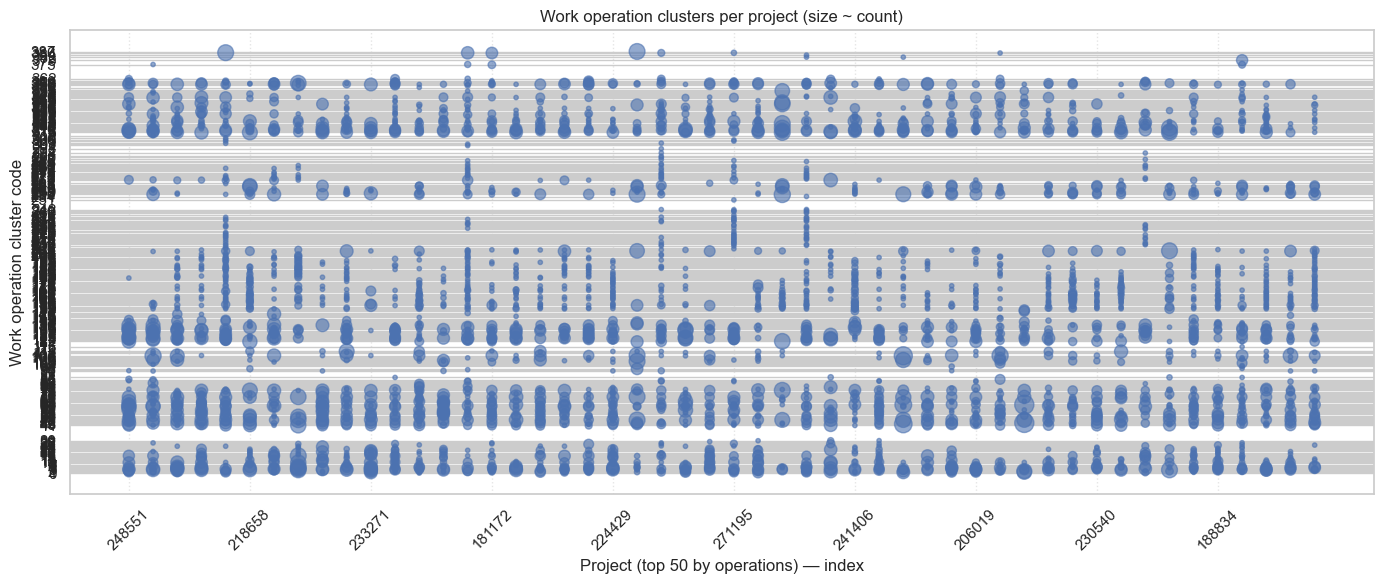

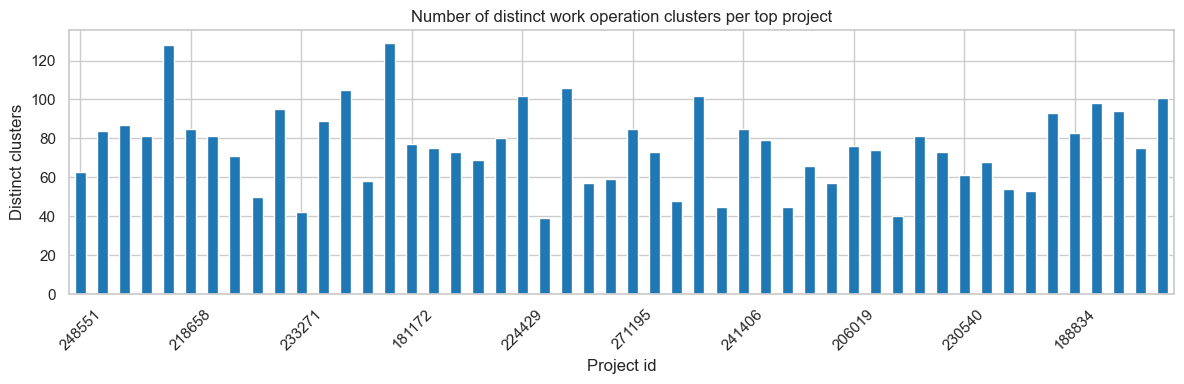

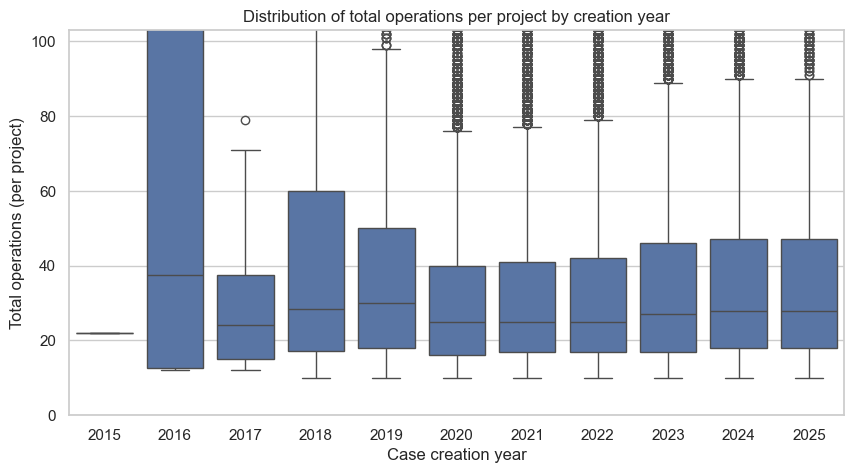

In [6]:
# Per-project job distribution
# group by project and work operation cluster
proj_ops = train.groupby(['project_id','work_operation_cluster_code']).size().reset_index(name='n_ops')

# choose top projects by total operations to keep plots readable
top_projects = train['project_id'].value_counts().head(50).index.tolist()
subset = proj_ops[proj_ops['project_id'].isin(top_projects)].copy()

# map project_id to an index for plotting
proj_order = list(top_projects)
proj_to_idx = {p:i for i,p in enumerate(proj_order)}
subset['proj_idx'] = subset['project_id'].map(proj_to_idx)

plt.figure(figsize=(14,6))
# jitter y a little for visibility
y = subset['work_operation_cluster_code'].astype(float)
plt.scatter(subset['proj_idx'], y + np.random.normal(0, 0.15, size=len(y)),
            s=np.clip(subset['n_ops']*5, 10, 600), alpha=0.6)
plt.yticks(sorted(subset['work_operation_cluster_code'].unique()))
plt.xlabel('Project (top 50 by operations) — index')
plt.ylabel('Work operation cluster code')
plt.title('Work operation clusters per project (size ~ count)')
plt.grid(axis='x', linestyle=':', alpha=0.5)
# put readable x labels (show every 5)
xticks = list(range(0, len(proj_order), 5))
plt.xticks(ticks=xticks, labels=[proj_order[i] for i in xticks], rotation=45)
plt.tight_layout()
plt.show()

# Summary: distinct number of operation clusters per project
distinct_ops = proj_ops.groupby('project_id')['work_operation_cluster_code'].nunique().reset_index(name='n_distinct_ops')
distinct_ops = distinct_ops[distinct_ops['project_id'].isin(top_projects)].set_index('project_id').loc[proj_order]

plt.figure(figsize=(12,4))
distinct_ops['n_distinct_ops'].plot(kind='bar', color='tab:blue')
plt.title('Number of distinct work operation clusters per top project')
plt.ylabel('Distinct clusters')
plt.xlabel('Project id')
plt.xticks(ticks=xticks, labels=[proj_order[i] for i in xticks], rotation=45)
plt.tight_layout()
plt.show()

# Merge with metaData to examine ops vs creation time (if metaData exists)
import os
meta_path = '../data/hackathon-recover-x-cogito/metaData.csv'
if os.path.exists(os.path.join(os.getcwd(), meta_path)) or os.path.exists(os.path.abspath(meta_path)):
    try:
        meta = pd.read_csv(meta_path)
        ops_per_proj = train.groupby('project_id').size().reset_index(name='total_ops')
        ops_meta = ops_per_proj.merge(meta[['project_id','case_creation_year','case_creation_month']], on='project_id', how='left')
        ops_meta['creation_ym'] = ops_meta['case_creation_year'].fillna(0).astype(int).astype(str) + '-' + ops_meta['case_creation_month'].fillna(0).astype(int).astype(str).str.zfill(2)
        # show relationship
        plt.figure(figsize=(10,5))
        sns.boxplot(x='case_creation_year', y='total_ops', data=ops_meta[ops_meta['case_creation_year'].notnull()])
        plt.title('Distribution of total operations per project by creation year')
        plt.ylabel('Total operations (per project)')
        plt.xlabel('Case creation year')
        plt.ylim(0, ops_meta['total_ops'].quantile(0.95))
        plt.show()
    except Exception as e:
        print('Could not load/merge metaData:', e)
else:
    print('metaData.csv not found at', meta_path)
